                                        Analisi Diffusione COVID-19 

Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. In particolare, il dataset si può scaricare dalla piattaforma o dall’indirizzo:
https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv 

1. Si richiede di verificare le dimensioni del dataset e i relativi metadati

In [1]:
# importazione librerie e database
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

covid_database = pd.read_csv("https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv")

#salvataggio database
covid_database.to_csv("covid_database.csv", index=False)

# -------------------------------------------
# ulteriori info su: https://github.com/owid/covid-19-data/blob/master/public/data/README.md

In [2]:
# verifica dimensioni dataset e metadati
covid_database.shape #(429435 righe, 67 colonne)
covid_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [3]:
#anteprima del database
covid_database.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [4]:
#verifica e conteggio valori nulli
covid_database.isna().sum()

iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64

In [5]:
# analisi database per capire le differenze tra le colonne "continent" e "location"
covid_database[["continent","location"]][2500:5000]

pd.options.display.max_rows = 999
covid_database[1673:1675]

# analisi database per capire le differenze tra le colonne "new_cases" e "total_cases"
afghanistan = covid_database[covid_database["location"]=="Afghanistan"]
new_cases_afg = afghanistan["new_cases"].sum()
print(f"Afghanistan: {new_cases_afg}")

afghanistan = covid_database[covid_database["location"]=="Afghanistan"]
total_cases_afg = afghanistan["total_cases"].max()
print(f"Afghanistan: {total_cases_afg}")

Afghanistan: 235214.0
Afghanistan: 235214.0


In [6]:
#verifica che la somma dei new_cases per stato corrisponda all'ultimo valore dei total_cases
somma_new_cases = covid_database.groupby("location")["new_cases"].sum()
continents = covid_database["continent"].dropna().unique().tolist() 
total_cases = covid_database.groupby("continent")["total_cases"].max()

somma_new_cases_continenti = somma_new_cases[somma_new_cases.index.isin(continents)]

confronto = pd.DataFrame({
    "total_cases": total_cases,
    "somma_new_cases": somma_new_cases_continenti
})
confronto
#location_to_continent = somma_new_cases.set_index("location")["continent"]
#somma_new_cases_con_continente = somma_new_cases.to_frame().join(location_to_continent, how="left")
#somma_new_cases_con_continente
#print(somma_new_cases_continent)
#print(total_cases)
#confronto = [somma_new_cases & total_cases]


,total_cases,somma_new_cases
Africa,4072765.0,13146831.0
Asia,99373219.0,301564180.0
Europe,38997490.0,252916868.0
North America,103436829.0,124492698.0
Oceania,11861161.0,15003468.0
South America,37511921.0,68811012.0


In [7]:
# identificazione continenti
covid_database["continent"].unique() #'Asia', nan, 'Europe', 'Africa', 'Oceania', 'North America','South America'

array(['Asia', nan, 'Europe', 'Africa', 'Oceania', 'North America',
       'South America'], dtype=object)

In [8]:
# identificazione stati/luoghi
locations = covid_database["location"].unique() 
locations

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda',
       'Argentina', 'Armenia', 'Aruba', 'Asia', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guine

2. Si chiede di trovare, per ogni continente:
   a. il numero di casi fin dall'inizio della pandemia

In [31]:
#per continente

print("Verifica del numero di casi fin dall'inizio della pandemia per continente:")
num_tot_mondo = 0
continents = covid_database["continent"].dropna().unique().tolist() 
continents.sort()
print(continents)

for continent in continents:
    num_tot_continent = covid_database[covid_database["continent"] == continent]["new_cases"].sum()
    print(f"{continent}: {num_tot_continent}")
    

Verifica del numero di casi fin dall'inizio della pandemia per continente:
['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
Africa: 13146831.0
Asia: 301564180.0
Europe: 252916868.0
North America: 124492698.0
Oceania: 15003468.0
South America: 68811012.0


2. Si chiede di trovare, per ogni continente:
   ...
   b. la percentuale rispetto al totale mondiale del numero di casi

Africa: 1.69%
Asia: 38.86%
Europe: 32.6%
North America: 16.04%
Oceania: 1.93%
South America: 8.87%


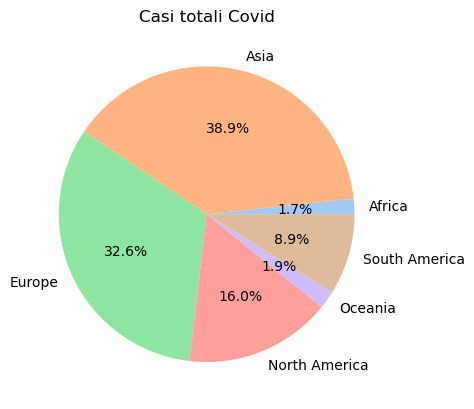

In [41]:
percentages = []
num_tot_mondo = covid_database[covid_database["location"] == "World"]["new_cases"].sum()

for continent in continents:
    num_tot_continent = covid_database[covid_database["continent"]==continent]["new_cases"].sum()
    percentage_continent = round((num_tot_continent / num_tot_mondo * 100), 2)
    
    percentages.append(percentage_continent)
    print(f"{continent}: {percentage_continent}%")


plt.pie(percentages, labels= continents, colors=sns.color_palette('pastel'), autopct='%1.1f%%')
plt.title("Casi totali Covid")
plt.show()

3. Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:
      a. l'evoluzione del casi totali dall'inizio alla fine dell'anno...

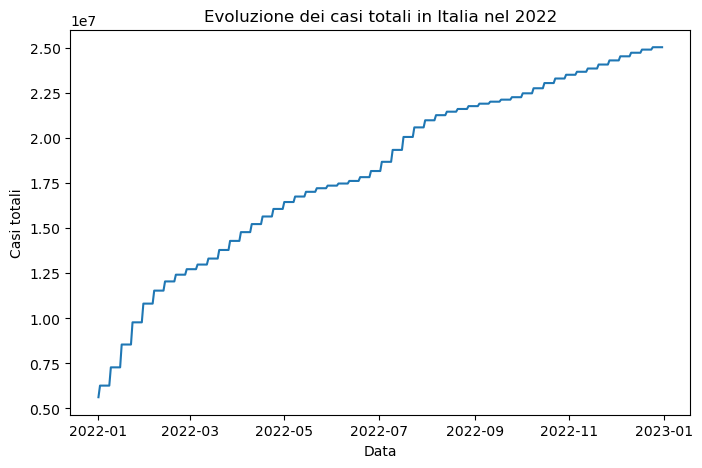

25060503.0

In [33]:
import time
import seaborn as sns
import matplotlib.pyplot as plt

#verifico formato della colonna data
covid_database["date"].dtype # non è datetime

#quindi converto in data tutta la colonna
covid_database["date"] = pd.to_datetime(covid_database["date"])

#separo anno in colonna a parte
covid_database["year"] = covid_database["date"].dt.year

#filtro per Italia
italia = covid_database[covid_database["location"]=="Italy"]

#italia["date"].info() #dtypes: datetime64[ns](1) OK

#italia["date"].isna().sum() #non ci sono nulli

# pulizia dati nulli in "new_cases" e filtro per il 2022

italia_2022_pulito = italia[(italia["year"] == 2022) & (italia["new_cases"].notna())]

italia_2022_pulito.to_csv("italia_2022_pulito.csv", index=False)

#grafico per evoluzione casi totali
plt.figure(figsize=(8,5))

grafico = sns.lineplot(data = italia_2022_pulito, x = "date", y = "total_cases")
plt.title("Evoluzione dei casi totali in Italia nel 2022")
plt.xlabel("Data")
plt.ylabel("Casi totali")

plt.show()

italia_2022_pulito["total_cases"].max()

3. Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:
   a. ...
   b. il numero di nuovi casi rispetto alla data

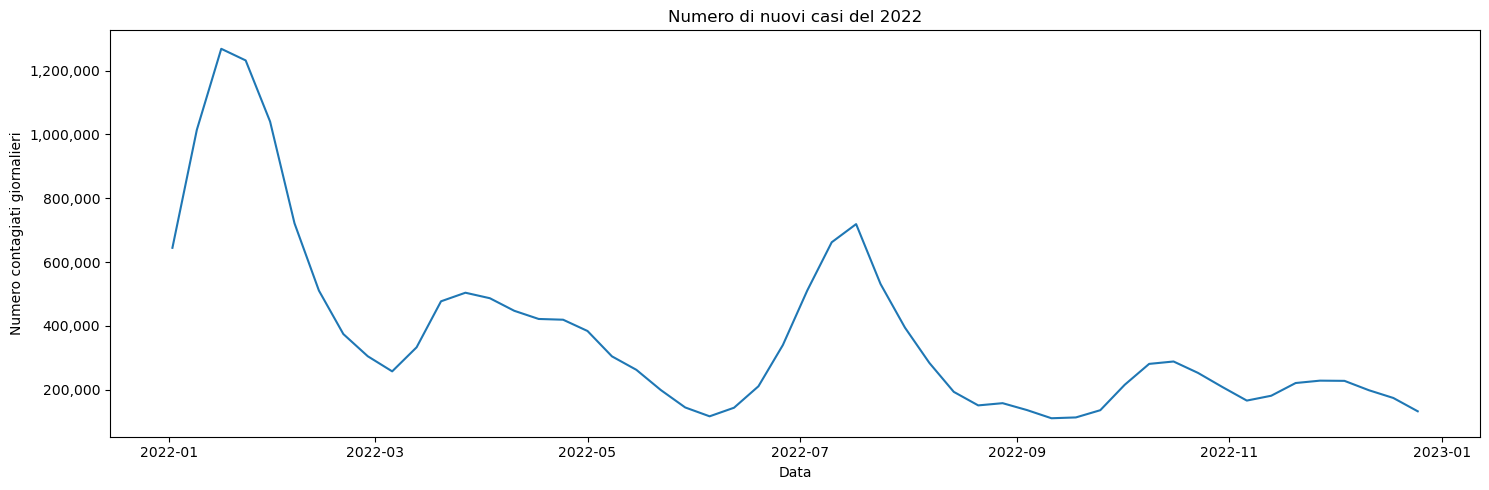

In [16]:
# grafico casi nuovi
plt.figure(figsize=(15,5))

grafico = sns.lineplot(data = italia_2022_pulito, x = "date", y = "new_cases")
plt.title("Numero di nuovi casi del 2022")
plt.xlabel("Data")
plt.ylabel("Numero contagiati giornalieri")

grafico.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

4. Riguardo le nazioni di Italia, Germania e Francia:
   a. mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva 
    (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 
    (incluso)...

Di seguito il numero di pazienti in terapia intensiva in:
location
France     334457.0
Germany    373171.0
Italy       84408.0
Name: icu_patients, dtype: float64


Text(0, 0.5, 'Numero pazienti')

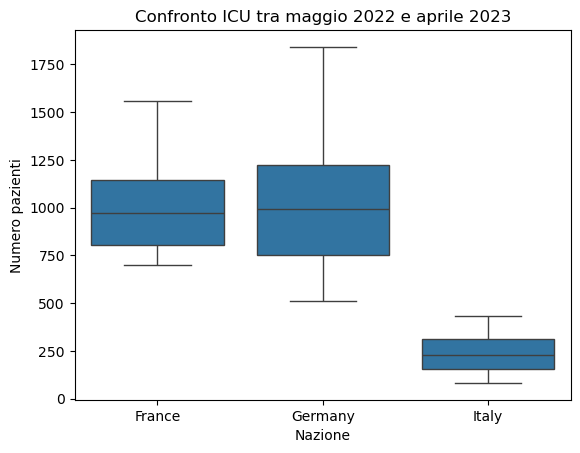

In [34]:
#filtro per data richiesta
covid_db_may2022_apr2023 = covid_database[(covid_database["date"] >= "2022-05-01") & 
                                                (covid_database["date"] <= "2023-04-30")]

#filtro per nazioni richieste 
covid_db_may2022_apr2023_ita_fra_ger = covid_db_may2022_apr2023["location"].isin(["Italy","France","Germany"])
covid_db_may2022_apr2023_ita_fra_ger = covid_db_may2022_apr2023[covid_db_may2022_apr2023_ita_fra_ger]
covid_db_may2022_apr2023_ita_fra_ger.to_csv("covid_db_may2022_apr2023_ita_fra_ger.csv", index=False)

#filtro per icu_patients
icu_may2022_apr2023 = covid_db_may2022_apr2023_ita_fra_ger.groupby("location")["icu_patients"].sum()
print("Di seguito il numero di pazienti in terapia intensiva in:")
print(icu_may2022_apr2023)

#creo boxplot
boxplot = sns.boxplot(data = covid_db_may2022_apr2023_ita_fra_ger, x = "location", y = "icu_patients")

plt.title("Confronto ICU tra maggio 2022 e aprile 2023")
plt.xlabel("Nazione")
plt.ylabel("Numero pazienti")

4. Riguardo le nazioni di Italia, Germania e Francia:
   a. ....
   b. scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico 
    risultante

Il grafico sopra riportato evidenzia che Francia e Germania hanno registrato valori di pazienti in ICU mediamente simili e maggiori rispetto a quelli rilevati in Italia, con distribuzioni simili tra loro.

5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
   a. mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)...

Di seguito il numero di pazienti ospitalizzati in:
  location  hosp_patients
0   France      6008717.0
1  Germany            0.0
2    Italy      4419950.0
3    Spain      2411706.0


Text(0, 0.5, 'Numero pazienti ospedalizzati')

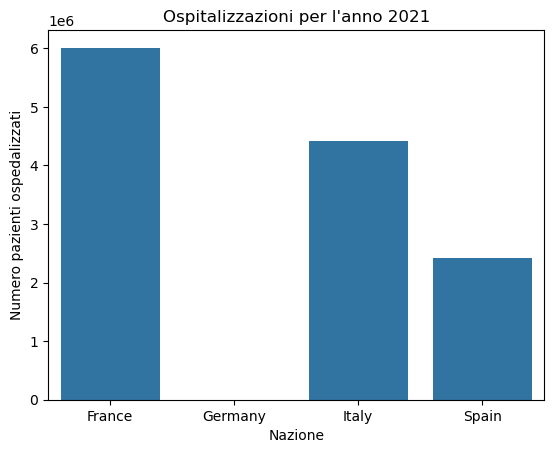

In [38]:
#filtro per data richiesta
covid_db_2021 = covid_database[(covid_database["date"] >= "2021-01-01") & (covid_database["date"] <= "2021-12-31")]

#filtro per nazioni richieste 
covid_db_2021_ita_fra_ger_esp = covid_db_2021[covid_db_2021["location"].isin(["Italy","France","Germany","Spain"])]
covid_db_2021_ita_fra_ger_esp.to_csv("covid_db_2021_ita_fra_ger_esp.csv", index=False)

#filtro per pazienti ospitalizzati
hosp_patients_2021_ita_fra_ger_esp = (covid_db_2021_ita_fra_ger_esp.groupby("location")
    ["hosp_patients"].sum().reset_index())
print("Di seguito il numero di pazienti ospitalizzati in:")
print(hosp_patients_2021_ita_fra_ger_esp)

#creo boxplot
boxplot = sns.barplot(data = hosp_patients_2021_ita_fra_ger_esp, x = "location", y = "hosp_patients")

plt.title("Ospitalizzazioni per l'anno 2021")
plt.xlabel("Nazione")
plt.ylabel("Numero pazienti ospedalizzati")


In [39]:
#verifica dati nulli nei 4 Stati

italy_null_hosp_patients_2021 = covid_db_2021[covid_db_2021["location"] == "Italy"]["hosp_patients"].isna().sum()
france_null_hosp_patients_2021 = covid_db_2021[covid_db_2021["location"] == "France"]["hosp_patients"].isna().sum()
germany_null_hosp_patients_2021 = covid_db_2021[covid_db_2021["location"] == "Germany"]["hosp_patients"].isna().sum()
spain_null_hosp_patients_2021 = covid_db_2021[covid_db_2021["location"] == "Spain"]["hosp_patients"].isna().sum()
print(f"Italia: {italy_null_hosp_patients_2021}\nFrancia: {france_null_hosp_patients_2021}\nGermania: {germany_null_hosp_patients_2021}\nSpagna: {spain_null_hosp_patients_2021}")

Italia: 0
Francia: 0
Germania: 365
Spagna: 0


5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
   a. ... 
   b. se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzioni o meno

Dall'analisi sopra riportata emerge che in Francia, Spagna e Italia non sono presenti dati nulli. Per quanto riguarda la Germania invece emerge che sono presenti 365 dati nulli, ovvero nessuna registrazione dei dati relativi alle ospitalizzazioni per l'anno 2021: per questo motivo non è rilevante sostituire o gestire tali dati in altro modo, perchè non sono proprio stati registrati.